# Импорт библиотек

In [114]:
import sys
import os

sys.path.append(os.path.abspath('lib'))

from filters_features_utils import FeatureSelector, FeatureSelectorCV, get_best_xgboost_features_names
from preprocessing_pipeline import create_combined_pipeline
from test_models import run_models_regressions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
from sklearn.metrics import mean_absolute_error, r2_score
from catboost import CatBoostRegressor

# Считывание данных

In [7]:
df = pd.read_csv('data/processed.csv')
df.shape

(998, 214)

# Очистка таргета от выбросов

(994, 214)


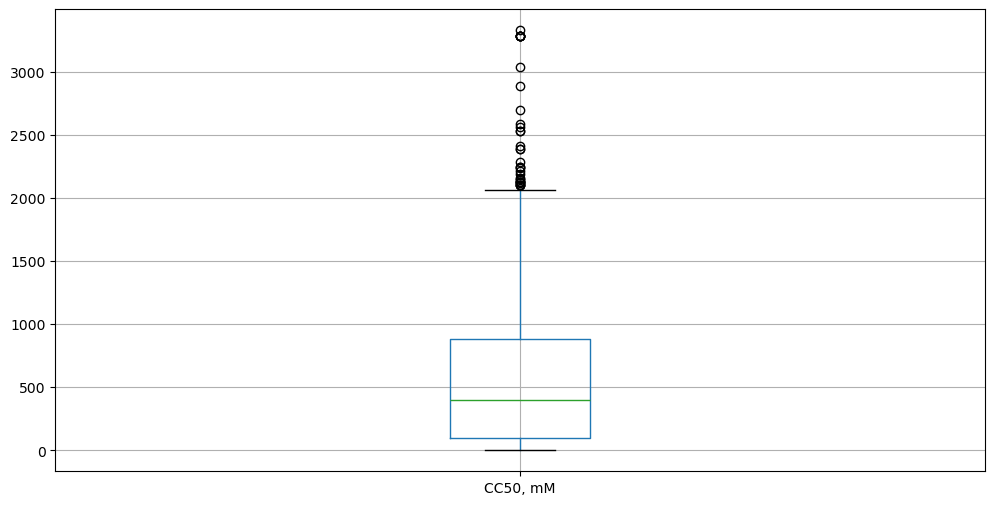

In [9]:
df = df[df['CC50, mM'] < 3500]
print(df.shape)
df.boxplot(column=['CC50, mM'], figsize=(12, 6))
plt.show()

# Подготовка данных для эксперемента

In [13]:
combined_pipeline = create_combined_pipeline()
X = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])
y1 = df['IC50, mM']
y2 = df['CC50, mM']
y3 = df['SI']
X_transformed = combined_pipeline.fit_transform(X)
df = pd.concat([X_transformed, y1, y2, y3], axis=1)
df.shape

(994, 110)

In [14]:
X = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])
y = df['CC50, mM']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train dataset size: {X_train.shape}, {y_train.shape}')
print(f'Test dataset size: {X_test.shape}, {y_test.shape}')

Train dataset size: (795, 107), (795,)
Test dataset size: (199, 107), (199,)


# Эксперемент с моделями

In [16]:
run_models_regressions(X_train, X_test, y_train, y_test)

,Model,Mean Absolute Error,R2 Score
6,LightGBM,286.36,0.56
7,CatBoost,306.06,0.55
3,Random Forest,286.98,0.54
4,XGBoost,285.29,0.54
5,Gradient Boosting,289.85,0.53
8,HistGradientBoosting,318.74,0.49
10,Krr,304.49,0.44
9,AdaBoost,402.85,0.38
0,Linear Regression,348.04,0.37
2,KNeighbors,285.75,0.37


# Фильтрация признаков

In [18]:
xgboost_features = get_best_xgboost_features_names(X_train, y_train, 100)

In [19]:
featureSelectorCV = FeatureSelectorCV()
featureSelectorCV.fit(X_train, y_train)

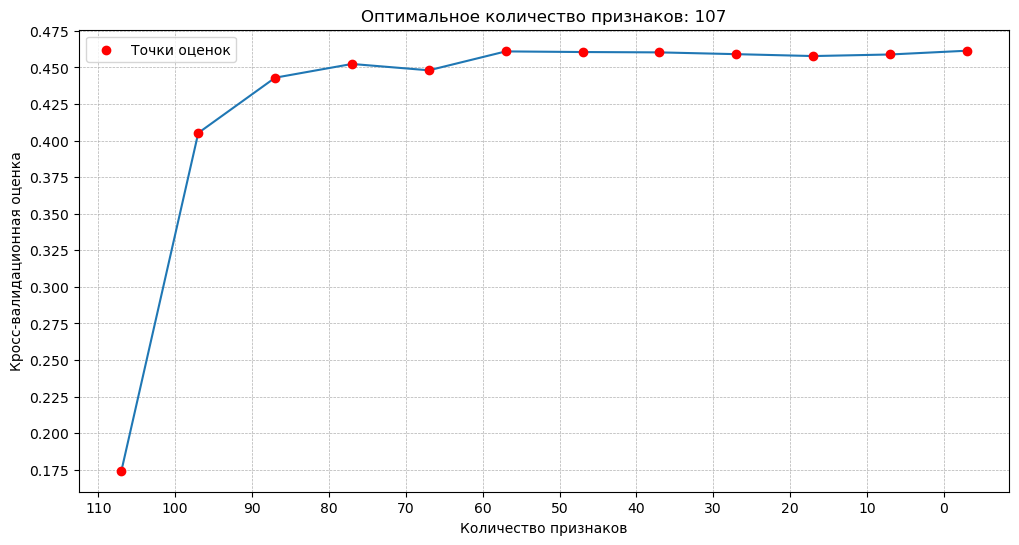

In [20]:
featureSelectorCV.plot_result()

In [21]:
model = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, random_seed=42, verbose=0)
featureSelector = FeatureSelector(model=model, start_index=5, step=5)

In [22]:
featureSelector.calculate_k_best(X_train, X_test, y_train, y_test)

K-Best Progress: 100%|██████████| 21/21 [00:06<00:00,  3.06it/s]


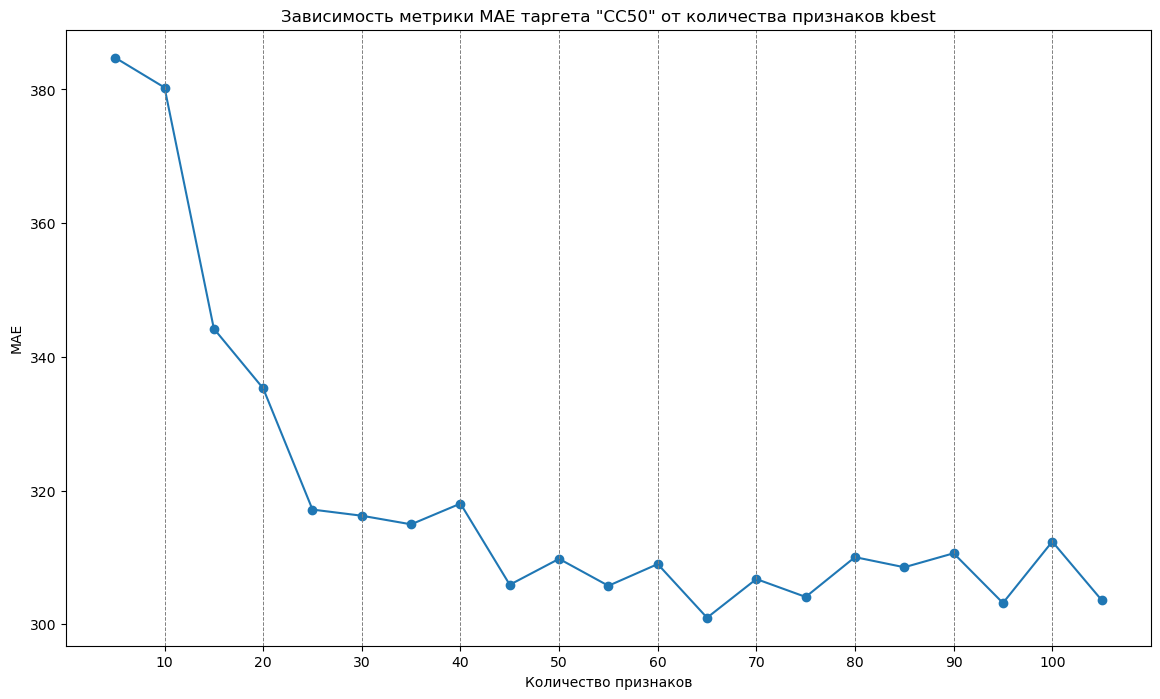

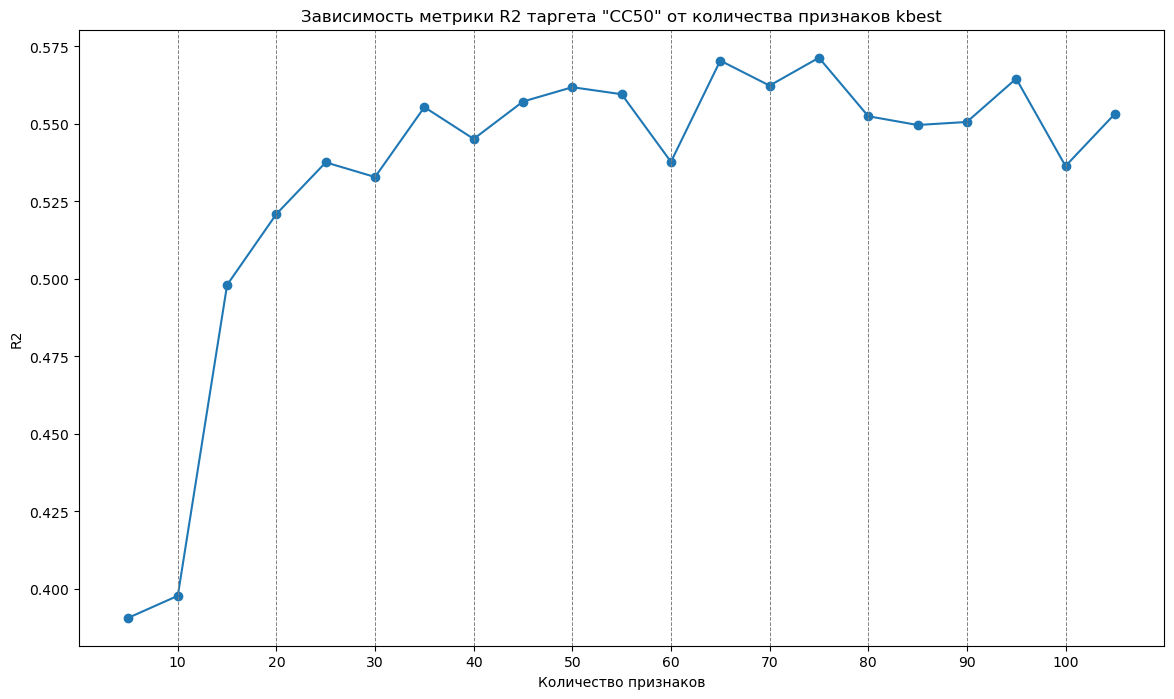

In [23]:
featureSelector.draw_selection(featureSelector.kbest_mae_scores, 'MAE', 'CC50', 'kbest')
featureSelector.draw_selection(featureSelector.kbest_r2_scores, 'R2', 'CC50', 'kbest')

In [24]:
featureSelector.calculate_rfe(X_train, X_test, y_train, y_test)

RFE Progress: 100%|██████████| 21/21 [02:04<00:00,  5.93s/it]


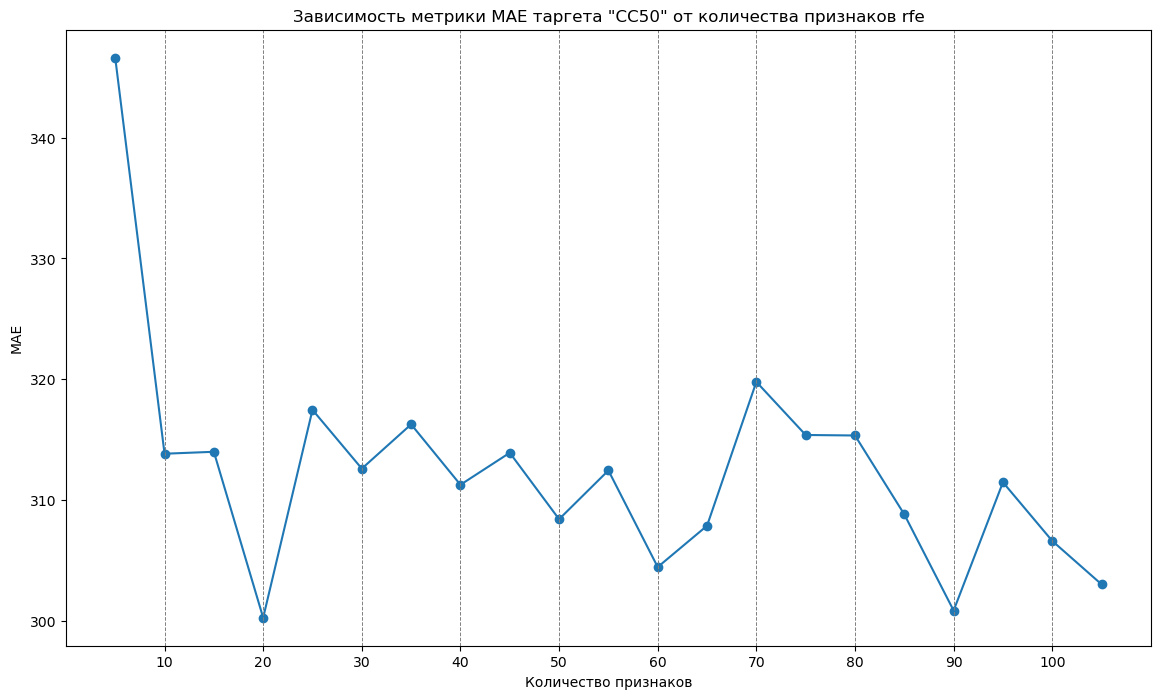

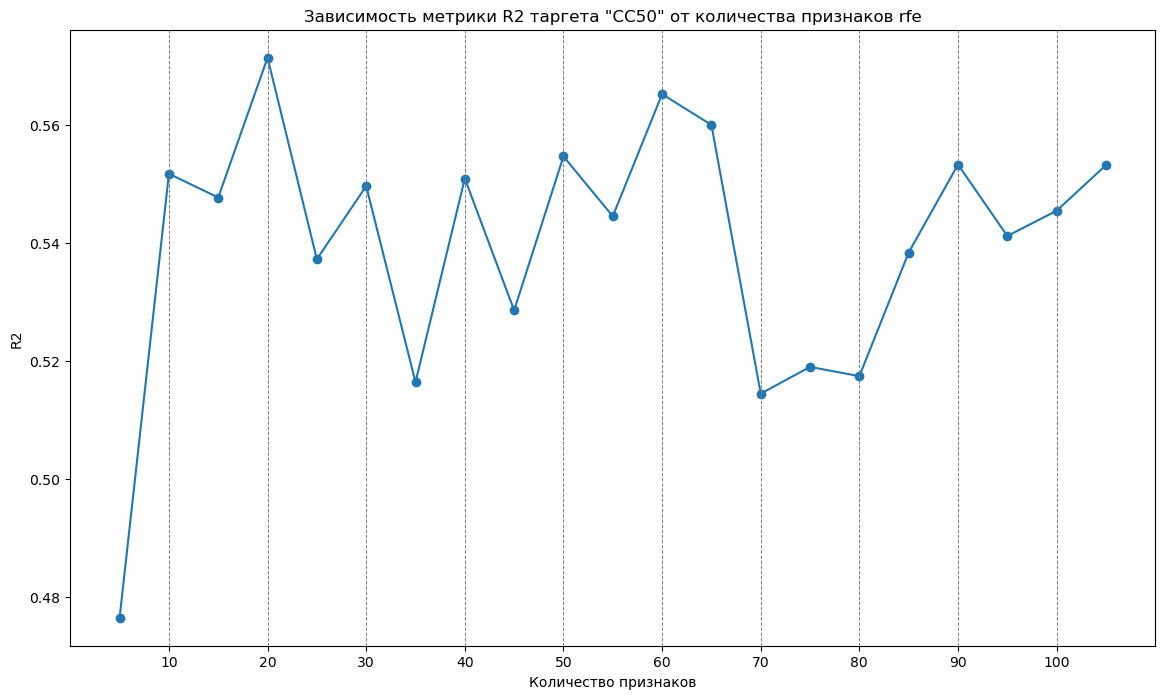

In [25]:
featureSelector.draw_selection(featureSelector.rfe_mae_scores, 'MAE', 'CC50', 'rfe')
featureSelector.draw_selection(featureSelector.rfe_r2_scores, 'R2', 'CC50', 'rfe')

In [26]:
featureSelector.print_kbest_result()

mae: 304.08263704783445
r2: 0.5713661029387385
Index(['element_index', 'MaxAbsEStateIndex', 'MinAbsEStateIndex',
       'MinEStateIndex', 'qed', 'SPS', 'MaxPartialCharge', 'HallKierAlpha',
       'Ipc', 'TPSA', 'NOCount', 'NumAliphaticCarbocycles',
       'NumAliphaticHeterocycles', 'NumAromaticHeterocycles',
       'NumAromaticRings', 'NumHDonors', 'NumRotatableBonds', 'MolLogP',
       'fr_Al_COO', 'fr_ArN', 'fr_Ar_COO', 'fr_Ar_NH', 'fr_Ar_OH', 'fr_C_O',
       'fr_C_S', 'fr_Imine', 'fr_NH0', 'fr_NH1', 'fr_NH2', 'fr_Ndealkylation1',
       'fr_alkyl_carbamate', 'fr_alkyl_halide', 'fr_allylic_oxid',
       'fr_amidine', 'fr_aniline', 'fr_benzene', 'fr_bicyclic', 'fr_epoxide',
       'fr_ester', 'fr_ether', 'fr_furan', 'fr_guanido', 'fr_hdrzone',
       'fr_ketone', 'fr_lactone', 'fr_methoxy', 'fr_nitrile', 'fr_oxime',
       'fr_para_hydroxylation', 'fr_piperzine', 'fr_priamide', 'fr_pyridine',
       'fr_quatN', 'fr_sulfide', 'fr_sulfonamd', 'fr_thiazole', 'fr_urea',
       'EState_V

In [27]:
featureSelector.print_rfe_result()

mae: 300.2883866474445
r2: 0.5714452212299879
Index(['MaxAbsEStateIndex', 'SPS', 'MaxPartialCharge', 'NHOHCount',
       'NumAliphaticHeterocycles', 'NumAromaticCarbocycles',
       'NumAromaticHeterocycles', 'fr_Imine', 'fr_NH2', 'EState_VSA_variation',
       'VSA_EState_median', 'VSA_EState_variation', 'PEOE_VSA_variation',
       'SMR_VSA_median', 'SMR_VSA_variation', 'SlogP_VSA_variation',
       'Chi_variation', 'BCUT2D_prod', 'BCUT2D_variation',
       'HeavyAtomFraction'],
      dtype='object')


In [28]:
common_selected_features, combined_selected_features = featureSelector.get_selected_features()

# Эксперемент с моделями

In [30]:
run_models_regressions(X_train, X_test, y_train, y_test)

,Model,Mean Absolute Error,R2 Score
6,LightGBM,286.36,0.56
7,CatBoost,306.06,0.55
3,Random Forest,286.98,0.54
4,XGBoost,285.29,0.54
5,Gradient Boosting,289.85,0.53
8,HistGradientBoosting,318.74,0.49
10,Krr,304.49,0.44
9,AdaBoost,402.85,0.38
0,Linear Regression,348.04,0.37
2,KNeighbors,285.75,0.37


In [31]:
run_models_regressions(X_train[xgboost_features], X_test[xgboost_features], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
6,LightGBM,285.91,0.56
3,Random Forest,285.69,0.54
7,CatBoost,314.27,0.54
4,XGBoost,288.24,0.53
5,Gradient Boosting,291.26,0.53
8,HistGradientBoosting,318.74,0.49
10,Krr,302.35,0.44
0,Linear Regression,346.47,0.38
2,KNeighbors,283.76,0.37
9,AdaBoost,410.77,0.37


In [32]:
run_models_regressions(X_train[featureSelectorCV.best_features_names], X_test[featureSelectorCV.best_features_names], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
6,LightGBM,286.36,0.56
7,CatBoost,306.06,0.55
3,Random Forest,286.98,0.54
4,XGBoost,285.29,0.54
5,Gradient Boosting,289.85,0.53
8,HistGradientBoosting,318.74,0.49
10,Krr,304.49,0.44
9,AdaBoost,402.85,0.38
0,Linear Regression,348.04,0.37
2,KNeighbors,285.75,0.37


In [33]:
selected_features = featureSelector.kbest_selected_features_list[featureSelector.kbest_features_index]
run_models_regressions(X_train[selected_features], X_test[selected_features], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
7,CatBoost,304.08,0.57
6,LightGBM,291.63,0.55
3,Random Forest,286.33,0.54
5,Gradient Boosting,283.17,0.54
4,XGBoost,292.38,0.53
8,HistGradientBoosting,311.64,0.51
10,Krr,324.60,0.38
0,Linear Regression,346.08,0.37
9,AdaBoost,410.04,0.37
2,KNeighbors,309.94,0.31


In [34]:
selected_features =  featureSelector.rfe_selected_features_list[featureSelector.rfe_features_index]
run_models_regressions(X_train[selected_features], X_test[selected_features], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
7,CatBoost,300.29,0.57
3,Random Forest,295.19,0.55
5,Gradient Boosting,303.29,0.50
4,XGBoost,303.58,0.49
6,LightGBM,307.25,0.49
8,HistGradientBoosting,338.05,0.44
9,AdaBoost,402.50,0.37
1,Decision Tree,329.20,0.29
10,Krr,412.96,0.18
0,Linear Regression,419.37,0.17


In [35]:
run_models_regressions(X_train[common_selected_features], X_test[common_selected_features], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
7,CatBoost,308.38,0.55
3,Random Forest,295.62,0.54
5,Gradient Boosting,300.61,0.50
6,LightGBM,315.23,0.47
4,XGBoost,313.40,0.46
8,HistGradientBoosting,335.62,0.45
9,AdaBoost,400.33,0.37
1,Decision Tree,337.20,0.24
0,Linear Regression,414.95,0.19
10,Krr,417.82,0.16


In [36]:
run_models_regressions(X_train[combined_selected_features], X_test[combined_selected_features], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
4,XGBoost,280.69,0.56
6,LightGBM,291.84,0.55
7,CatBoost,310.27,0.55
3,Random Forest,290.20,0.53
5,Gradient Boosting,286.89,0.53
8,HistGradientBoosting,320.68,0.48
10,Krr,322.69,0.40
0,Linear Regression,347.59,0.37
9,AdaBoost,424.88,0.32
2,KNeighbors,306.12,0.31


# Подбор гиперпараметров

In [117]:
model = CatBoostRegressor(verbose=0, random_seed=42)
param_dist = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5],
    'bagging_temperature': [0, 1, 2]
}

best_catboost = GridSearchCV(
    estimator=model,
    param_grid=param_dist,
    scoring='r2',
    cv=5,
    n_jobs=-1
)
best_catboost.fit(X_train, y_train)

print("Лучшие гиперпараметры:", best_catboost.best_params_)

y_pred = best_catboost.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R2 Score: {r2:.2f}')

Лучшие гиперпараметры: {'bagging_temperature': 0, 'depth': 6, 'iterations': 300, 'l2_leaf_reg': 5, 'learning_rate': 0.05}
Mean Absolute Error: 304.90
R2 Score: 0.55


In [118]:
train_indices = np.full((X_train.shape[0],), -1)
test_indices = np.full((X_test.shape[0],), 0)
test_fold = np.concatenate([train_indices, test_indices])

ps = PredefinedSplit(test_fold)

X_combined = np.vstack((X_train, X_test))
y_combined = np.concatenate((y_train, y_test))

In [119]:
param_grid = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5],
    'bagging_temperature': [0, 1, 2]
}
model = CatBoostRegressor(verbose=0, random_seed=42)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='r2',
    cv=ps,
    n_jobs=-1
)
grid_search.fit(X_combined, y_combined)

print("Лучшие гиперпараметры:", grid_search.best_params_)

y_pred = grid_search.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae:.2f}')
print(f'R2 Score: {r2:.2f}')

Лучшие гиперпараметры: {'bagging_temperature': 0, 'depth': 6, 'iterations': 300, 'l2_leaf_reg': 5, 'learning_rate': 0.1}
Mean Absolute Error: 151.77
R2 Score: 0.89


In [131]:
best_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    random_seed=725,
    bagging_temperature=0,
    l2_leaf_reg=5,
    verbose=0,
)
best_model.fit(X_train[featureSelector.rfe_best_feature_names], y_train)
y_pred = best_model.predict(X_test[featureSelector.rfe_best_feature_names])

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae:.3f}')
print(f'R2 Score: {r2:.3f}')

Mean Absolute Error: 281.067
R2 Score: 0.590
